# Project 2: Policy Change
## Quantified Cognition
### Psychology 5332


# Name: *Amber Trinh*
# User ID: *att8nms*

## Option 3: Apply the Successor Representation model to a new RL Problem

In class we applied the successor representation (SR) to the Frozen Lake example provided by the AI Gymnasium.

For this option, your task would be to apply the SR to an RL problem that we did not already solve. Some options would be:

- Another one of the text-based environments on the AI Gymnasium: https://gymnasium.farama.org/environments/toy_text/
  The reason to use the text-based environments is that they have lower numbers of states that do not require deep convolutional networks to define. 
  
- Some other problem that you propose. I'm happy to work with you to decide on another problem you'd like to apply the SR (or some other RL-model) to solve.

In your write-up, be sure to clearly define your problem, how you assessed model performance (e.g., reward earned for each game, number of trials to learn, etc...), describe what changes you had to make to the parameters to attain the performance you did, and, optionally, explore the effect different model parameters have on performance.

In [ ]:
# to install more libraries
!pip install gymnasium

In [1]:
# load matplotlib inline mode
%matplotlib inline

# import some useful libraries
import numpy as np                # numerical analysis linear algebra
import matplotlib.pyplot as plt   # plotting

from IPython.display import display, clear_output, Image
import time

from fastprogress.fastprogress import master_bar, progress_bar

import gymnasium as gym
from gymnasium.envs.toy_text import cliffwalking

# Updated Policy + Revisit Penalty

o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
x  C  C  C  C  C  C  C  C  C  C  T




None

Mean final performance: -13.0
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
x  C  C  C  C  C  C  C  C  C  C  T




None

Mean final performance: -13.0
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
x  C  C  C  C  C  C  C  C  C  C  T




...

Mean final performance: -13.0
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
x  C  C  C  C  C  C  C  C  C  C  T




None

Mean final performance: -13.0
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
x  C  C  C  C  C  C  C  C  C  C  T




None

Mean final performance: -13.0

Average Final Performance Means from 10 Environments:  -13.4

Average Number of Trials Needed to Learn from 10 Environments:  303.0


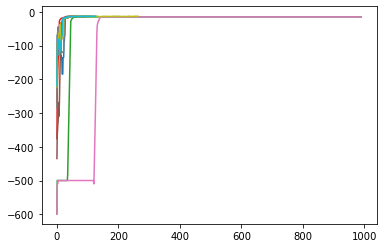

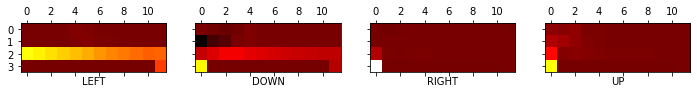

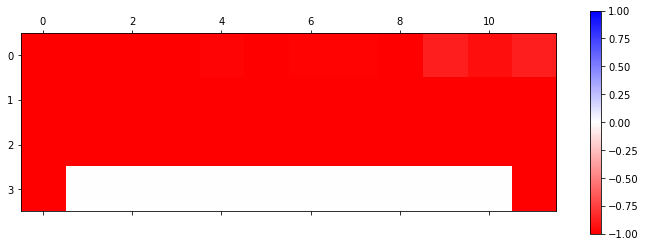

In [32]:
# keep track
final_performance_means = []
num_trials_needed = []

for environment in range(10):
    # CELL 1
    
    # define the environment
    gym.make('CliffWalking-v0')

    # generate map
    env = cliffwalking.CliffWalkingEnv(render_mode='ansi')

    ## reset the environment and get the initial state
    observation, info = env.reset()
    total_rewards = 0 # added this counter
    display(print(env.render()))
    
    # CELL 2
    
    # params
    gamma = .95
    alpha = .5
    rho = .25
    tau = 10.0
    p_rand = 0.0
    hole_penalty = -1.0
    off_board_penalty = -0.0
    revisit_penalty = 0.25

    # set up our agent
    # pull out the number of actions and unique states
    n_actions = env.action_space.n
    n_states = env.observation_space.n

    # create orthogonal state representations
    states = np.eye(n_states)

    # allocate for where we learn:
    # rewards associated with each state
    rewards = np.zeros(n_states)
    # states associated with each other (via SR)
    M = np.zeros((n_actions, n_states, n_states))

    # keep track of scores during learning
    scores = []

    # define a policy 
    # !!!!! MODIFY THIS CODE TO UPDATE THE POLICY !!!!
    def pick_action(f0, t0, M, rewards, tau, p_rand=0.0):
        # apply policy to pick action
        if p_rand > 0.0 and np.random.rand() < p_rand:
            # pick a random action
            action = env.action_space.sample()
        else:
            # Q = np.dot(np.dot(M, f0), rewards)
            Q = np.dot(np.dot(M, f0), (rewards-t0*revisit_penalty)) # account for punishment based on where it's been recently (t0)
            #action = np.random.choice(np.where(Q==Q.max())[0])
            #action = np.argmax(Q)
            pQ = np.exp(Q*tau)/np.exp(Q*tau).sum()
            action = np.argmax(np.random.rand() < np.cumsum(pQ))
        return action
    
    # CELL 3
    
    ntrials = 1000
    max_moves = 500
    max_corr = 25

    for r in progress_bar(range(ntrials)):
        # reset for new attempt at recovering the frisbee
        observation, info = env.reset()
        total_rewards = 0
        last_obs = observation
        f0 = states[observation]
        t0 = states[observation]

        # set current annealing
        cur_p_rand = p_rand*(1-((r+1)/ntrials))

        for i in range(max_moves):
            # pick an action
            action = pick_action(f0, t0, M, rewards, tau, p_rand=cur_p_rand)  

            # observe new state
            observation, reward, trunc, done, info = env.step(action)
            total_rewards+=reward

            # turn the new state into a vector representation
            f1 = states[observation]

            # learn via successor representation
            # prediction from previous state
            p0 = np.dot(M[action], f0)

            # observed outcome, plus discounted future prediction
            # when following that policy
            f1_action = pick_action(f1, t0, M, rewards, tau, p_rand=cur_p_rand)
            o1 = (f1 + gamma*(np.dot(M[f1_action], f1)))

            # update the association for that action
            M[action] += alpha * np.outer((o1 - p0), t0)

            # update context (eligibility trace)
            #t1 = rho*t0 + (1-rho)*f1
            t1 = np.clip(rho*t0 + f1, 0, 1)

            # process the reward if any
            if trunc and reward==0:
                # get negative rewards for falling in a hole
                reward = hole_penalty

            if last_obs == observation:
                # action gave rise to no change in movement
                reward = off_board_penalty

            #if reward == 0:
            #    # punish going to a state and not getting anything for it
            #    rewards[last_obs] -= .1

            # update our representation of rewards/punishments at the observed state
            rewards[observation] += alpha*(reward - rewards[observation])

            # see if we're done
            if trunc:
                #print("Episode finished after {} timesteps with reward {}".format(i+1, reward))
                # save out our final reward/punishment
                scores.append(total_rewards)
                break

            # prepare for next iteration
            f0 = f1
            t0 = t1
            last_obs = observation

        # if we ran out of time, say we fell in
        if i==(max_moves-1):
            scores.append(total_rewards)

        if len(scores)>max_corr and np.mean(scores[-max_corr:])==-13.0:
            # we're consistently solving it, so quit
            break

    # render the final state
    env.render()

    # plot a moving average of scores
    N=10
    plt.plot(np.convolve(scores, np.ones((N,))/N, mode='valid'))

    print("Mean final performance:", np.mean(scores[-max_corr:]))
    
    # append mean final performance to list for all environments:
    final_performance_means.append(np.mean(scores[-max_corr:]))
    
    # appen how many number of trials needed to learn 25 in a row (length of scores) in each new environment
    num_trials_needed.append(len(scores))
    

print("\nAverage Final Performance Means from 10 Environments: ", np.mean(final_performance_means[-10:]))
print("\nAverage Number of Trials Needed to Learn from 10 Environments: ", np.mean(num_trials_needed[-10:]))

# see predicted outcomes for different actions at a particular state
state = 36
fig,ax = plt.subplots(1, 4, figsize=(12,5), sharex=True, sharey=True)
acts = ['LEFT', 'DOWN', 'RIGHT', 'UP']

# get the min and max values for plot normalization
pmin = 0.0
pmax = 0.0
for i in range(n_actions):
    pred = np.dot(M, states[state])[i]
    pmin = min(pred.min(), pmin)
    pmax = max(pred.max(), pmax)

# do the plot
for i in range(n_actions):
    pred = np.dot(M, states[state])[i]
    ax[i].matshow((pred.reshape((4, 12))), vmin=pmin, vmax=pmax, cmap='hot')
    ax[i].set_xlabel(acts[i]) 
    

# see what state rewards it's learned
plt.matshow(rewards.reshape((4, 12)), cmap='bwr_r', vmin=-1.0, vmax=1.0)
plt.colorbar()

# Updated Policy + No Revisit Penalty

o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
x  C  C  C  C  C  C  C  C  C  C  T




None

Mean final performance: -13.0
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
x  C  C  C  C  C  C  C  C  C  C  T




None

Mean final performance: -13.0
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
x  C  C  C  C  C  C  C  C  C  C  T




...

Mean final performance: -13.0
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
x  C  C  C  C  C  C  C  C  C  C  T




None

Mean final performance: -500.0
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
x  C  C  C  C  C  C  C  C  C  C  T




None

Mean final performance: -15.0

Average Final Performance Means from 10 Environments:  -62.5

Average Number of Trials Needed to Learn from 10 Environments:  451.6


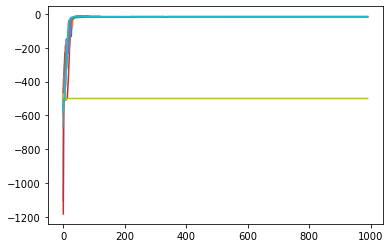

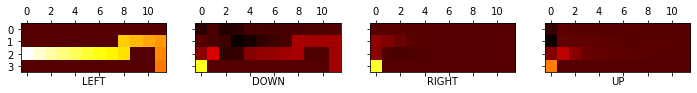

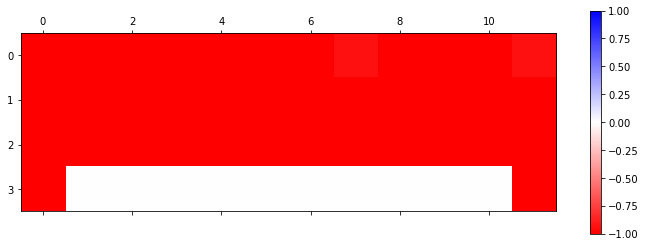

In [31]:
# keep track
final_performance_means = []
num_trials_needed = []

for environment in range(10):
    # CELL 1
    
    # define the environment
    gym.make('CliffWalking-v0')

    # generate map
    env = cliffwalking.CliffWalkingEnv(render_mode='ansi')

    ## reset the environment and get the initial state
    observation, info = env.reset()
    total_rewards = 0 # added counter here
    display(print(env.render()))
    
    # CELL 2
    
    # params
    gamma = .95
    alpha = .5
    rho = .25
    tau = 10.0
    p_rand = 0.0
    hole_penalty = -1.0
    off_board_penalty = -0.0
    revisit_penalty = 0.0

    # set up our agent
    # pull out the number of actions and unique states
    n_actions = env.action_space.n
    n_states = env.observation_space.n

    # create orthogonal state representations
    states = np.eye(n_states)

    # allocate for where we learn:
    # rewards associated with each state
    rewards = np.zeros(n_states)
    # states associated with each other (via SR)
    M = np.zeros((n_actions, n_states, n_states))

    # keep track of scores during learning
    scores = []

    # define a policy 
    # !!!!! MODIFY THIS CODE TO UPDATE THE POLICY !!!!
    def pick_action(f0, t0, M, rewards, tau, p_rand=0.0):
        # apply policy to pick action
        if p_rand > 0.0 and np.random.rand() < p_rand:
            # pick a random action
            action = env.action_space.sample()
        else:
            # Q = np.dot(np.dot(M, f0), rewards)
            Q = np.dot(np.dot(M, f0), (rewards-t0*revisit_penalty)) # account for punishment based on where it's been recently (t0)
            #action = np.random.choice(np.where(Q==Q.max())[0])
            #action = np.argmax(Q)
            pQ = np.exp(Q*tau)/np.exp(Q*tau).sum()
            action = np.argmax(np.random.rand() < np.cumsum(pQ))
        return action
    
    # CELL 3
    
    ntrials = 1000
    max_moves = 500
    max_corr = 25

    for r in progress_bar(range(ntrials)):
        # reset for new attempt at recovering the frisbee
        observation, info = env.reset()
        total_rewards = 0  # added counter here
        last_obs = observation
        f0 = states[observation]
        t0 = states[observation]

        # set current annealing
        cur_p_rand = p_rand*(1-((r+1)/ntrials))

        for i in range(max_moves):
            # pick an action
            action = pick_action(f0, t0, M, rewards, tau, p_rand=cur_p_rand)  

            # observe new state
            observation, reward, trunc, done, info = env.step(action)
            total_rewards+=reward

            # turn the new state into a vector representation
            f1 = states[observation]

            # learn via successor representation
            # prediction from previous state
            p0 = np.dot(M[action], f0)

            # observed outcome, plus discounted future prediction
            # when following that policy
            f1_action = pick_action(f1, t0, M, rewards, tau, p_rand=cur_p_rand)
            o1 = (f1 + gamma*(np.dot(M[f1_action], f1)))

            # update the association for that action
            M[action] += alpha * np.outer((o1 - p0), t0)

            # update context (eligibility trace)
            #t1 = rho*t0 + (1-rho)*f1
            t1 = np.clip(rho*t0 + f1, 0, 1)

            # process the reward if any
            if trunc and reward==0:
                # get negative rewards for falling in a hole
                reward = hole_penalty

            if last_obs == observation:
                # action gave rise to no change in movement
                reward = off_board_penalty

            #if reward == 0:
            #    # punish going to a state and not getting anything for it
            #    rewards[last_obs] -= .1

            # update our representation of rewards/punishments at the observed state
            rewards[observation] += alpha*(reward - rewards[observation])

            # see if we're done
            if trunc:
                #print("Episode finished after {} timesteps with reward {}".format(i+1, reward))
                # save out our final reward/punishment
                scores.append(total_rewards)
                break

            # prepare for next iteration
            f0 = f1
            t0 = t1
            last_obs = observation

        # if we ran out of time, say we fell in
        if i==(max_moves-1):
            scores.append(total_rewards)

        if len(scores)>max_corr and np.mean(scores[-max_corr:])==-13.0:
            # we're consistently solving it, so quit
            break

    # render the final state
    env.render()

    # plot a moving average of scores
    N=10
    plt.plot(np.convolve(scores, np.ones((N,))/N, mode='valid'))

    print("Mean final performance:", np.mean(scores[-max_corr:]))
    
    # append mean final performance to list for all environments:
    final_performance_means.append(np.mean(scores[-max_corr:]))
    
    # appen how many number of trials needed to learn 25 in a row (length of scores) in each new environment
    num_trials_needed.append(len(scores))
    

print("\nAverage Final Performance Means from 10 Environments: ", np.mean(final_performance_means[-10:]))
print("\nAverage Number of Trials Needed to Learn from 10 Environments: ", np.mean(num_trials_needed[-10:]))

# see predicted outcomes for different actions at a particular state
state = 36
fig,ax = plt.subplots(1, 4, figsize=(12,5), sharex=True, sharey=True)
acts = ['LEFT', 'DOWN', 'RIGHT', 'UP']

# get the min and max values for plot normalization
pmin = 0.0
pmax = 0.0
for i in range(n_actions):
    pred = np.dot(M, states[state])[i]
    pmin = min(pred.min(), pmin)
    pmax = max(pred.max(), pmax)

# do the plot
for i in range(n_actions):
    pred = np.dot(M, states[state])[i]
    ax[i].matshow((pred.reshape((4, 12))), vmin=pmin, vmax=pmax, cmap='hot')
    ax[i].set_xlabel(acts[i]) 
    

# see what state rewards it's learned
plt.matshow(rewards.reshape((4, 12)), cmap='bwr_r', vmin=-1.0, vmax=1.0)
plt.colorbar()

### Write your short answer here to the questions listed above:

#### Clearly define your problem:

###### Goal: 
- The goal of this cliffwalking game is to move across the grid world from the starting position to the goal while avoiding falling off a cliff. 

###### Environment:

- The environment itself is a 4 x 12 grid world. 
- The starting position is at [3,0] (state 36)
- The goal is located at [3,11] (state 47)
- The cliff runs along [3,1..10].

##### Mechanics: 
- The agent can move up, down, left, or right. 
- The episode ends when the agent reaches the goal
- With each step, the agent incurs -1 reward unless the agent steps off the cliff, incurring a -100 reward.

##### Problems: 
- Can the model learn to take the optimal path the agent from start to goal to incur the least amount of punishments, in other words, minimize its punishments?
- Can the agent learn without positive rewards?
- When modifying the policy of the model to allow for more exploration when learning, does penalizing revisitations of states help or hurt learning? 






#### How did you assessed model performance (e.g., reward earned for each game, number of trials to learn, etc...)
- I assessed model performance via the final performance means over 10 iterations as well as the average number of trials needed to learn from 10 iterations
- If each iteration produced a final performance mean of -13, this indicated that the model learned perfectly as the optimal path from start to goal is right along the cliff in 13 timesteps, resulting in a total of -13 punishments at the end of the episode, each step incurring a -1 punishment
- Each iteration will stop as soon as the mean of the last 25 attempts is -13. If it gets it right 25 times in a row, this indicates it has made it to the goal location and stop as it has learned perfectly. 
- To quantify and compare whether the agent learned faster in a condition (revisit penalty vs. no revisit penalty), I tested how many trials it took to learn given 10 environments in each condition.



#### Describe what changes you had to make to the parameters to attain the performance you did?
- I added a revisit_penalty scalar parameter to each condition in order to update the policy to punish the agent for making movements to states it's been recently and assess whether revisitation of a state would help or hurt learning.
- In the revisit penalty condition: revist_penalty = 0.25. Minimal negativity for recently encountered states, but not too punishing. 
- In the no revisit penalty condition: revisit_penalty = 0.0
- I didn't need to change the rewards structure since I allowed the environment to tell me the reward associated with each state. 



#### Why can the model learn to solve the problem perfectly without a positive reward?
- It's because the model is using the successor representation. 
- Before the model does punishments, it's the expected number of revisitations to all other states given that you were at one state and you took the action to move in a direction.
- If the state only finishes when you get to the goal and you're moving towards the goal, you will have a lower number of expected visitations to all other states because at some point, it will be in the vicinity of the goal and end.
- But if you move away from the goal, you will have a greater number of expected visitations before it finishes. 
- Therefore, when calculating Q-value, the expected visitations of all the states other than the cliff (each one giving a -1), if you make an action that increases your number of expected visitations, then it will take more steps to get to goal if going in a direction other than towards the goal.
- If each state is a -1, going away from the goal will incurr a greater negative score than going toward the goal. For example, being in the middle of the map and going right will incur a -20 score while going left toward the goal will incur a -12 score.
- The model is making a decision based on what's going to maximize its rewards, which also means minimizing punishments.
- Therefore, using the example given previously, when calculating the probability (pQ) it's saying that -12/-20 + -12 is a number that is a lot bigger than -20/-20 + -12. when it turns it into a probability of making each choice.
- The expected number of visitations is greater than when you go in a direction that's away from getting to the endpoint.
- This is demonstrated by the plots of the successor representations for being in some location and 4 different options of movements. The plots print out the different actions and their respective probabilities of taking each choice given where you are in the map. 



#### Does the model learn faster when you penalize more for revisiting recent states? 

- The results show that penalizing revisitation of recent states does better than without the revisitation penalty based on the mean number of trials it takes to learn and mean performance. This suggests that the penalty helped improve and speed up learning.


#### Even if it never reaches the criterion, is it solvinging more or less often with the penalty?

- Since both conditions vary in whether they max their trials in each run or not, resulting in a similar mean trials to learn, this suggests that it never learns to criterion in either revisit_penalty condition. However, it also looks like having a revisitation penalty performed better than with it based on the the mean performance, suggesting that the no revisitation penalty hurts learning. 


#### Why do you think you observed what you did?

- Since the successor representation depends on where you've been in the environment, the Q values will be more negative if you're moving away from the goal than it will be positive, which is how it learns once it gets to the endpoint.
